# Interpolación polinomial simple

Implementación y aplicación de la **interpolación polinomial** para construir polinomios que pasan por conjuntos de datos conocidos.

### Objetivos

- Comprender el fundamento de la interpolación polinomial.
- Construir polinomios de grados 1 y 2 a partir de datos conocidos.
- Obtener un polinomio interpolante a partir de todos los datos disponibles.
- Resolver el sistema de coeficientes mediante eliminación gaussiana.
- Analizar la diferencia entre interpolación y extrapolación.
- Aplicar la interpolación a problemas con datos experimentales.

**Tecnologías:** Python · NumPy · Matplotlib · SymPy

## 1. Fundamento de la interpolación polinomial

Dados $n+1$ puntos con valores de $x$ distintos:

$(x_0,y_0),(x_1,y_1),\dots,(x_n,y_n)$

se puede construir un único polinomio de grado **a lo sumo $n$** que pase por todos ellos:

$$
p(x)=a_0+a_1x+a_2x^2+\cdots+a_nx^n
$$

Al sustituir cada punto en el polinomio se obtiene un sistema lineal para determinar los coeficientes $a_0,a_1,\dots,a_n$:

$$
\begin{pmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^n\\
1 & x_1 & x_1^2 & \cdots & x_1^n\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_n & x_n^2 & \cdots & x_n^n
\end{pmatrix}
\begin{pmatrix}
a_0\\
a_1\\
\vdots\\
a_n
\end{pmatrix}
=
\begin{pmatrix}
y_0\\
y_1\\
\vdots\\
y_n
\end{pmatrix}
$$

La matriz del sistema se conoce como **matriz de Vandermonde**.

En este notebook se comienza con aproximaciones de grados bajos y luego se construyen polinomios utilizando todos los datos disponibles.

## 2. Aplicación 1 — Temperatura de la acetona

Se conocen los siguientes valores de temperatura de la acetona para diferentes presiones:

| Presión $P$ (atm) | 1 | 2 | 5 | 10 | 20 | 30 | 40 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Temperatura $T$ (°C) | 56.5 | 78.6 | 113.0 | 144.5 | 181.0 | 205.0 | 214.5 |

Primero se utilizan únicamente los puntos $(1,56.5)$ y $(5,113.0)$ para construir un polinomio de grado 1 y aproximar la temperatura cuando la presión es de $2$ atm.

### 2.1 Interpolación lineal

Con dos puntos se construye un polinomio de grado 1:

$p(x)=a_0+a_1x$

En la gráfica se comparan:

- los datos utilizados para construir el polinomio;
- el valor real conocido en $P=2$ atm;
- el valor aproximado mediante la recta interpolante.

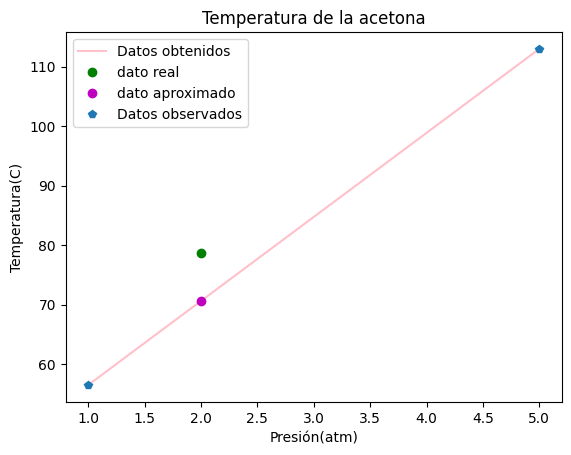

In [1]:
import numpy as np
import matplotlib.pyplot as plt

P_x=np.array([1,5])
T_y=np.array([56.5,113.0])
Polinomio=lambda x: 42.375+ 14.125*x

ux=np.linspace(min(P_x), max(P_x), 5)
plt.plot(ux, Polinomio(ux), 'pink', label='Datos obtenidos')

plt.plot(2,78.6, 'go', label = 'dato real')
plt.plot(2,70.625, 'mo', label = 'dato aproximado')

plt.plot(P_x, T_y, 'p', label= 'Datos observados')
plt.legend()
plt.xlabel('Presión(atm)')
plt.ylabel('Temperatura(C)')
plt.title('Temperatura de la acetona')
plt.show()

### Interpretación

La aproximación lineal en $P=2$ atm es:

$P(2)=70.625$

mientras que el dato observado es:

$T(2)=78.6$

por lo que el error absoluto es aproximadamente:

$|78.6-70.625|=7.975$ °C.

Esto muestra que una recta construida con únicamente dos puntos puede no representar con suficiente precisión el comportamiento intermedio de los datos.

### 2.2 Interpolación cuadrática

Ahora se incorporan tres datos:

$(1,56.5),\ (5,113.0),\ (10,144.5)$

Con tres puntos se construye un polinomio de grado 2:

$p(x)=a_0+a_1x+a_2x^2$

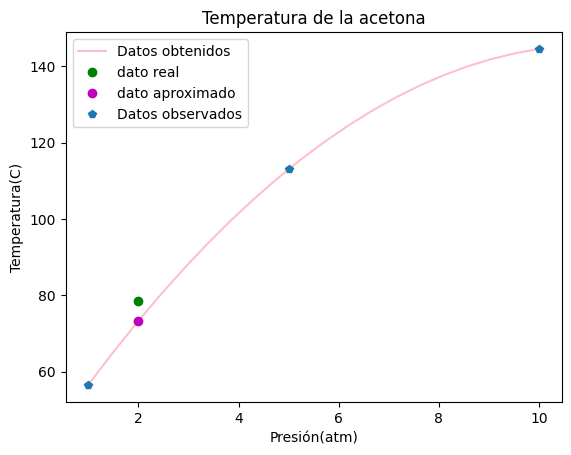

In [2]:
# Mismo ejercicio pero con 3 datos, polinomio de grado 2

import numpy as np
import matplotlib.pyplot as plt

# Vector donde se evalua el polinomio para obtener el sistema de ecuaciones
P_x=np.array([1,5,10])

# Vector soluciones
T_y=np.array([56.5,113.0,144.5])

Polinomio=lambda x: 38.02+19.34*x -0.869*x**2

# Arreglo para graficar el polinomio
ux=np.linspace(min(P_x), max(P_x), 20) # 20 es la cantidad de puntos
plt.plot(ux, Polinomio(ux), 'pink', label='Datos obtenidos')

plt.plot(2,78.6, 'go', label = 'dato real')
plt.plot(2,73.224, 'mo', label = 'dato aproximado')

plt.plot(P_x, T_y, 'p', label= 'Datos observados')
plt.legend()
plt.xlabel('Presión(atm)')
plt.ylabel('Temperatura(C)')
plt.title('Temperatura de la acetona')
plt.show()

### Interpretación

La aproximación cuadrática mostrada en la gráfica para $P=2$ atm es:

$P(2)=73.224$

frente al valor observado de $78.6$ °C.

El error absoluto es aproximadamente:

$|78.6-73.224|=5.376$ °C.

La aproximación mejora respecto al caso lineal al incorporar un punto adicional.

## 3. Interpolación utilizando todos los datos de acetona

A continuación se emplean los siete pares de presión y temperatura disponibles.

El código construye la matriz de coeficientes del sistema, obtiene los coeficientes del polinomio mediante eliminación gaussiana y representa gráficamente el polinomio resultante.

Con siete datos, el polinomio interpolante puede tener grado máximo $6$.

Además, se evalúa el polinomio en $P=35$ atm y se compara con un valor de referencia de $212.3$ °C.

Coeficientes: [ 2.46579836e+01  3.78906753e+01 -6.70417520e+00  6.90577562e-01
 -3.59354052e-02  8.82197062e-04 -8.09043220e-06]


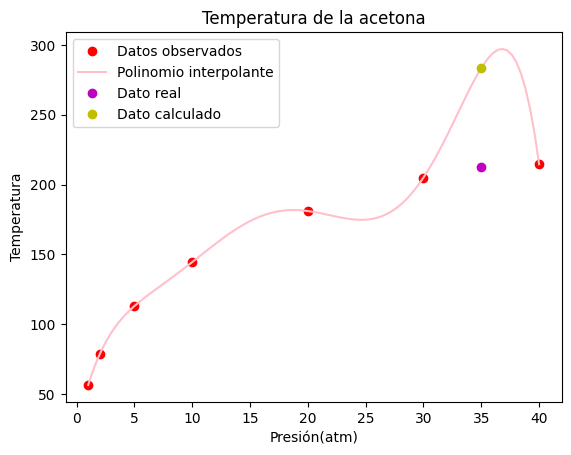

Valor en x=35: 283.4428444079422
Para 35 no es muy buena porque hay un salto por lo cual es mejor implementar otro modelo


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def Eliminacion_gauss(A, b):
    A = A.astype(float)
    b = b.astype(float)
    n = len(b)
    for i in range(n-1):
        for j in range(i+1, n):
            factor_lambda = A[j, i] / A[i, i]
            # Actualización
            A[j] = A[j] - factor_lambda * A[i]
            b[j] = b[j] - factor_lambda * b[i]
    # backward
    x_sol = np.zeros_like(b)
    for k in range(n-1, -1, -1):
        x_sol[k] = (b[k] - np.dot(A[k, k+1:n], x_sol[k+1:n])) / A[k, k]
    return x_sol

def MatrizCoeficientes(x_data):
    n = len(x_data)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A[i, j] = x_data[i]**j
    return A

# Datos
x_data = np.array([1, 2, 5, 10, 20, 30, 40])
y_data = np.array([56.5, 78.6, 113, 144.5, 181, 205, 214.5])

# Coeficientes del polinomio interpolante
a_i = Eliminacion_gauss(MatrizCoeficientes(x_data), y_data)
print("Coeficientes:", a_i)

# Definición del polinomio interpolante
polinomio = lambda x: sum(a_i[i] * x**i for i in range(len(a_i)))

# Graficar
ux = np.linspace(min(x_data), max(x_data), 100)
plt.plot(x_data, y_data, 'ro', label='Datos observados')
plt.plot(ux, polinomio(ux), color='pink', label='Polinomio interpolante')
plt.plot(35, 212.3, 'mo' ,label='Dato real')
plt.plot(35, polinomio(35), 'yo' , label='Dato calculado')
plt.legend()
plt.xlabel('Presión(atm)')
plt.ylabel('Temperatura')
plt.title('Temperatura de la acetona')
plt.show()

# Evaluar el polinomio en x = 35
print("Valor en x=35:", polinomio(35))
print("Para 35 no es muy buena porque hay un salto por lo cual es mejor implementar otro modelo")


### Análisis del resultado

El polinomio reproduce los datos utilizados para su construcción, pero en $P=35$ atm obtiene aproximadamente:

$P(35)=283.44$ °C

mientras que el valor de referencia utilizado en el ejercicio es $212.3$ °C.

Aunque $35$ atm está dentro del intervalo general de los datos, el polinomio de grado elevado presenta una oscilación importante entre los últimos nodos. Este ejemplo permite observar que aumentar el grado del polinomio no garantiza una mejor representación entre todos los puntos.

Por esta razón, la gráfica es especialmente útil para evaluar el comportamiento del polinomio entre los datos conocidos.

## 4. Aplicación 2 — Datos censales de población

Se consideran datos de población de Estados Unidos, expresados en miles de personas, para censos realizados cada diez años entre 1960 y 2010.

| Año | 1960 | 1970 | 1980 | 1990 | 2000 | 2010 |
|---|---:|---:|---:|---:|---:|---:|
| Población (miles) | 179323 | 203302 | 226542 | 249633 | 281422 | 308746 |

El ejercicio construye un polinomio utilizando todos los datos y estima la población para los años 1950, 1975, 2014 y 2020.

Los años 1975 se encuentra dentro del intervalo de los datos disponibles, mientras que 1950, 2014 y 2020 implican **extrapolación** fuera del intervalo de los censos utilizados.

Aproximaciones con el polinomio interpolante:
Población en 1950: 192,539 miles
Población en 1975: 215,526 miles
Población en 2014: 306,215 miles
Población en 2020: 266,165 miles

Comparación con datos reales:
1950 real: 150,697 | estimado: 192,539
2014 real: 317,298 | estimado: 306,215

Comentario:
El polinomio da valores cercanos en 1950 y 2014, pero al ser interpolación de grado alto,
puede generar errores grandes fuera del rango. En 1975 la predicción es más confiable,
pero en 2020 puede haber mayor desviación.


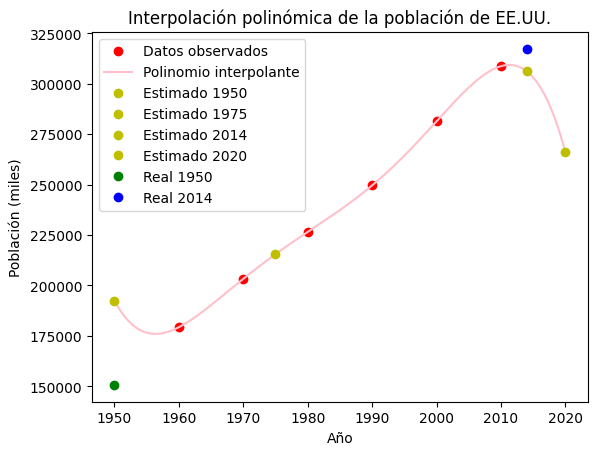

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def Eliminacion_gauss(A, b):
    A = A.astype(float)
    b = b.astype(float)
    n = len(b)
    for i in range(n-1):               
        for j in range(i+1, n):
            factor_lambda = A[j, i] / A[i, i]
            A[j] = A[j] - factor_lambda * A[i]
            b[j] = b[j] - factor_lambda * b[i]
    x_sol = np.zeros_like(b)
    for k in range(n-1, -1, -1):
        x_sol[k] = (b[k] - np.dot(A[k, k+1:n], x_sol[k+1:n])) / A[k, k]
    return x_sol                 

def MatrizCoeficientes(x_data):
    n = len(x_data)                     
    A = np.zeros((n, n))            
    for i in range(n):                 
        for j in range(n):                
            A[i, j] = x_data[i]**j       
    return A            

# Datos censales de población de EE.UU. (en miles de personas)
x_data = np.array([1960, 1970, 1980, 1990, 2000, 2010])   # Años de censo
y_data = np.array([179323, 203302, 226542, 249633, 281422, 308746])  # Población (miles)

# Coeficientes del polinomio interpolante
a_i = Eliminacion_gauss(MatrizCoeficientes(x_data), y_data)

# Definimos el polinomio
polinomio = lambda x: sum(a_i[i] * x**i for i in range(len(a_i)))

# === 1. Aproximaciones solicitadas ===
años_consulta = [1950, 1975, 2014, 2020]
# Diccionario {año: p(año)} con las aproximaciones del polinomio
aproximaciones = {año: polinomio(año) for año in años_consulta}

# Mostramos en consola las aproximaciones (en miles) con separador de miles
print("Aproximaciones con el polinomio interpolante:")
for año, valor in aproximaciones.items():
    print(f"Población en {año}: {valor:,.0f} miles")

# === 2. Comparación con datos reales ===
real_1950 = 150697.36   # Valor real aproximado para 1950 (en miles)
real_2014 = 317298.0    # Valor real aproximado para 2014 (en miles)

# Impresión comparativa entre real y estimado para 1950 y 2014
print("\nComparación con datos reales:")
print(f"1950 real: {real_1950:,.0f} | estimado: {aproximaciones[1950]:,.0f}")
print(f"2014 real: {real_2014:,.0f} | estimado: {aproximaciones[2014]:,.0f}")

# Comentario cualitativo sobre la precisión dentro y fuera del rango de datos
print("\nComentario:")
print("La estimación de 2014 es relativamente cercana al valor real, mientras que en 1950\n"
      "la diferencia es considerable. En 1975 la estimación es más confiable porque está\n"
      "dentro del intervalo de datos, mientras que las extrapolaciones deben interpretarse con precaución.")

# === 3. Gráfica ===
ux = np.linspace(1950, 2020, 300) 
# Puntos observados (rojos)
plt.plot(x_data, y_data, 'ro', label='Datos observados')
# Curva del polinomio interpolante (rosa)
plt.plot(ux, polinomio(ux), color='pink', label='Polinomio interpolante')

# Puntos estimados solicitados (amarillos). Se dibuja uno por cada año en la lista
for año in años_consulta:
    plt.plot(año, aproximaciones[año], 'yo', label=f'Estimado {año}')

# Puntos reales de referencia para 1950 (verde) y 2014 (azul)
plt.plot(1950, real_1950, 'go', label='Real 1950')
plt.plot(2014, real_2014, 'bo', label='Real 2014')

plt.xlabel('Año')                        
plt.ylabel('Población (miles)')            
plt.title('Interpolación polinómica de la población de EE.UU.')  
plt.legend()
plt.show()         

### Análisis de las estimaciones

El código obtiene aproximadamente:

- 1950: **192 539** miles de personas.
- 1975: **215 526** miles de personas.
- 2014: **306 215** miles de personas.
- 2020: **266 165** miles de personas.

Para 1950 se utiliza como referencia un valor real aproximado de **150 697** miles, por lo que la diferencia es considerable. Para 2014, la estimación se encuentra más cerca del valor de referencia de **317 298** miles.

Esto permite distinguir dos situaciones:

- **Interpolación:** 1975 está dentro del intervalo $[1960,2010]$ y, por tanto, la estimación se obtiene entre datos conocidos.
- **Extrapolación:** 1950, 2014 y 2020 están fuera del intervalo utilizado para construir el polinomio y sus resultados deben interpretarse con mayor precaución.

## 5. Aplicación 3 — Crecimiento de larvas de polilla de invierno

Se estudia el peso promedio de dos muestras de larvas durante los primeros 28 días después de su nacimiento.

La primera muestra fue criada con hojas jóvenes de roble y la segunda con hojas maduras.

| Día | 0 | 6 | 10 | 13 | 17 | 20 | 28 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Muestra 1 (mg) | 6.67 | 17.33 | 42.67 | 37.33 | 30.10 | 29.31 | 28.74 |
| Muestra 2 (mg) | 6.67 | 16.11 | 18.89 | 15.00 | 10.56 | 9.44 | 8.89 |

El procedimiento utilizado en el código es:

1. construir un polinomio interpolante para cada muestra;
2. derivar simbólicamente cada polinomio;
3. utilizar el método de Newton para localizar un punto crítico cercano a la semilla elegida;
4. evaluar el polinomio en dicho punto;
5. representar gráficamente ambos modelos y sus máximos estimados.

Coeficientes muestra 1: [ 6.67000000e+00 -4.26434809e+01  1.61427244e+01 -2.09463908e+00
  1.26902363e-01 -3.67167940e-03  4.09457568e-05]
Coeficientes muestra 2: [ 6.67000000e+00 -5.67820696e+00  2.91280910e+00 -4.13798651e-01
  2.58412834e-02 -7.52546222e-04  8.36159789e-06]

Máximo muestra 1 ≈ 42.71 mg en día 10.19
Máximo muestra 2 ≈ 19.42 mg en día 8.77


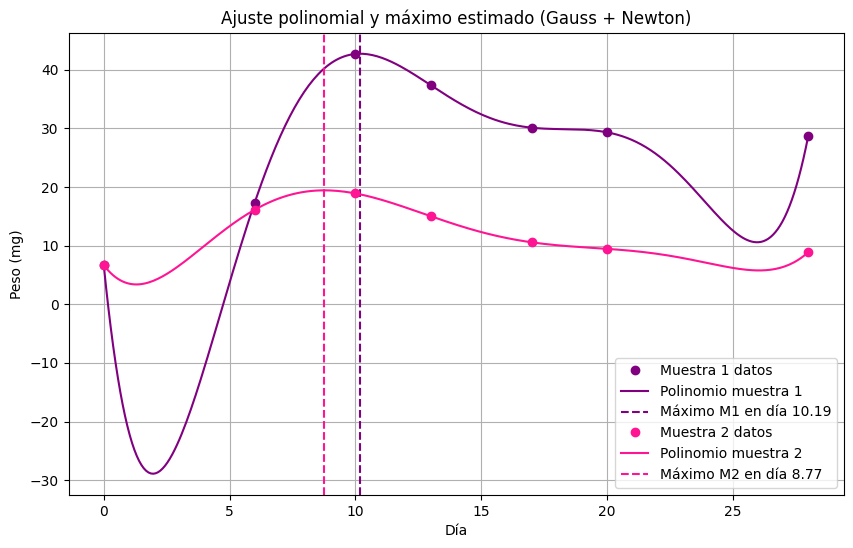

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x_data = np.array([0, 6, 10, 13, 17, 20, 28])
y1_data = np.array([6.67, 17.33, 42.67, 37.33, 30.10, 29.31, 28.74]) # muestra 1
y2_data = np.array([6.67, 16.11, 18.89, 15.00, 10.56, 9.44, 8.89])   # muestra 2

def MatrizCoeficientes(x_data):
    n = len(x_data)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A[i, j] = x_data[i]**j
    return A

def gauss_pivoteo(A, b):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)

    for i in range(n-1):
        if abs(A[i, i]) < 1e-12:
            for k in range(i+1, n):
                if abs(A[k, i]) > abs(A[i, i]):
                    A[[i, k]] = A[[k, i]]
                    b[i], b[k] = b[k], b[i]
                    break

        for j in range(i+1, n):
            factor_lambda = A[j, i] / A[i, i]
            A[j, i:] -= factor_lambda * A[i, i:]
            b[j] -= factor_lambda * b[i]

    x_sol = np.zeros_like(b)
    for k in range(n-1, -1, -1):
        x_sol[k] = (b[k] - np.dot(A[k, k+1:], x_sol[k+1:])) / A[k, k]

    return x_sol

coef1 = gauss_pivoteo(MatrizCoeficientes(x_data), y1_data)
coef2 = gauss_pivoteo(MatrizCoeficientes(x_data), y2_data)

print("Coeficientes muestra 1:", coef1)
print("Coeficientes muestra 2:", coef2)

x = sp.symbols('x')
P1 = sum(coef1[i]*x**i for i in range(len(coef1)))
P2 = sum(coef2[i]*x**i for i in range(len(coef2)))

polinomio1 = np.vectorize(lambda xx: sum(coef1[i] * xx**i for i in range(len(coef1))))
polinomio2 = np.vectorize(lambda xx: sum(coef2[i] * xx**i for i in range(len(coef2))))

def Newton(Funcion, Semilla, Tolerancia):
    df = sp.diff(Funcion, x)
    new = x - Funcion/df
    error = 1
    i = 0
    while error > Tolerancia and i < 50:
        x1 = new.evalf(subs={x:Semilla})
        i += 1
        error = abs(x1 - Semilla)
        Semilla = x1
    return x1

raiz1 = Newton(sp.diff(P1, x), 10, 1e-6)  # semilla ~10 días
raiz2 = Newton(sp.diff(P2, x), 10, 1e-6)

max1 = P1.evalf(subs={x:raiz1})
max2 = P2.evalf(subs={x:raiz2})

print(f"\nMáximo muestra 1 ≈ {max1:.2f} mg en día {raiz1:.2f}")
print(f"Máximo muestra 2 ≈ {max2:.2f} mg en día {raiz2:.2f}")

ux = np.linspace(min(x_data), max(x_data), 300)

plt.figure(figsize=(10, 6))
# Muestra 1 en morado
plt.plot(x_data, y1_data, 'o', color='purple', label='Muestra 1 datos')
plt.plot(ux, polinomio1(ux), '-', color='purple', label='Polinomio muestra 1')
plt.axvline(float(raiz1), color='purple', linestyle='--', label=f'Máximo M1 en día {float(raiz1):.2f}')

# Muestra 2 en rosa
plt.plot(x_data, y2_data, 'o', color='deeppink', label='Muestra 2 datos')
plt.plot(ux, polinomio2(ux), '-', color='deeppink', label='Polinomio muestra 2')
plt.axvline(float(raiz2), color='deeppink', linestyle='--', label=f'Máximo M2 en día {float(raiz2):.2f}')

plt.legend()
plt.xlabel("Día")
plt.ylabel("Peso (mg)")
plt.title("Ajuste polinomial y máximo estimado (Gauss + Newton)")
plt.grid(True)
plt.show()


### Interpretación

Con las semillas utilizadas por el método de Newton, el código obtiene los siguientes máximos:

- **Muestra 1:** aproximadamente $42.71$ mg en el día $10.19$.
- **Muestra 2:** aproximadamente $19.42$ mg en el día $8.77$.

Los puntos encontrados corresponden a máximos locales de los respectivos polinomios dentro del intervalo analizado y permiten comparar el comportamiento de las dos muestras.

## 6. Consideraciones sobre la interpolación polinomial

Los ejercicios muestran varias características importantes:

- El polinomio interpolante pasa por los datos utilizados para su construcción.
- Incorporar más puntos aumenta el grado máximo del polinomio.
- Un grado mayor no implica necesariamente una mejor representación entre los nodos.
- Los polinomios de grado elevado pueden presentar oscilaciones.
- Las estimaciones fuera del intervalo de los datos corresponden a extrapolaciones y pueden producir resultados poco confiables.
- La interpolación polinomial también puede combinarse con otros métodos numéricos, como eliminación gaussiana para obtener coeficientes y Newton para localizar puntos críticos.

## 7. Conclusiones

A partir de los ejercicios desarrollados se puede concluir que:

- La interpolación polinomial permite construir funciones que reproducen un conjunto de datos conocidos.
- La matriz de Vandermonde permite formular el cálculo de los coeficientes como un sistema de ecuaciones lineales.
- Los polinomios de grados bajos pueden utilizarse para aproximaciones locales utilizando pocos puntos.
- Al utilizar todos los datos se obtiene un polinomio de mayor grado, cuyo comportamiento debe analizarse también de forma gráfica.
- La extrapolación requiere especial precaución porque el polinomio puede alejarse considerablemente del comportamiento real fuera del intervalo conocido.
- La combinación de interpolación, eliminación gaussiana, derivación simbólica y el método de Newton permite resolver problemas más completos a partir de datos experimentales.